In [1]:
# Cell 1: Clone repo và chuyển nhánh
!git clone https://github.com/BHVPhuc/Lab03_AI.git
%cd Lab03_AI
!git checkout feature/mnist

Cloning into 'Lab03_AI'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 53 (delta 18), reused 44 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 19.37 KiB | 4.84 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/kaggle/working/Lab03_AI
Branch 'feature/mnist' set up to track remote branch 'feature/mnist' from 'origin'.
Switched to a new branch 'feature/mnist'


In [2]:
# Cell 2: Cài đặt thư viện
!apt-get install graphviz -y
!pip install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 90 not upgraded.


In [3]:
# Cell 3: Import và load dữ liệu
import os
print("Current dir:", os.getcwd())
!ls -la


Current dir: /kaggle/working/Lab03_AI
total 56
drwxr-xr-x 7 root root 4096 Jun 26 06:06 .
drwxr-xr-x 4 root root 4096 Jun 26 06:06 ..
drwxr-xr-x 2 root root 4096 Jun 26 06:06 figures
drwxr-xr-x 8 root root 4096 Jun 26 06:06 .git
-rw-r--r-- 1 root root 6753 Jun 26 06:06 Guide.md
drwxr-xr-x 2 root root 4096 Jun 26 06:06 notebooks
-rw-r--r-- 1 root root 4765 Jun 26 06:06 PROGRESS.md
-rw-r--r-- 1 root root 5111 Jun 26 06:06 README.md
drwxr-xr-x 2 root root 4096 Jun 26 06:06 report
-rw-r--r-- 1 root root   69 Jun 26 06:06 requirements.txt
drwxr-xr-x 2 root root 4096 Jun 26 06:06 utils


In [4]:
# Cell 4: Chia train/val
import sys
sys.path.append('.')
from utils.helpers import load_mnist_data, stratified_split, plot_class_distribution

# Kiểm tra xem hàm đã được import chưa
print("Hàm stratified_split đã sẵn sàng:", "stratified_split" in dir())

Hàm stratified_split đã sẵn sàng: True


In [5]:
# Cell 5: Load dữ liệu và chia Trial
X_train, y_train, X_test, y_test = load_mnist_data()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

X_train, y_train, X_val, y_val = stratified_split(X_train, y_train, val_size=0.2)
print(f"Train size: {X_train.shape[0]}, Val size: {X_val.shape[0]}")

Train: (60000, 784), Test: (10000, 784)
Train size: 48000, Val size: 12000


/kaggle/working/Lab03_AI/utils/helpers.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


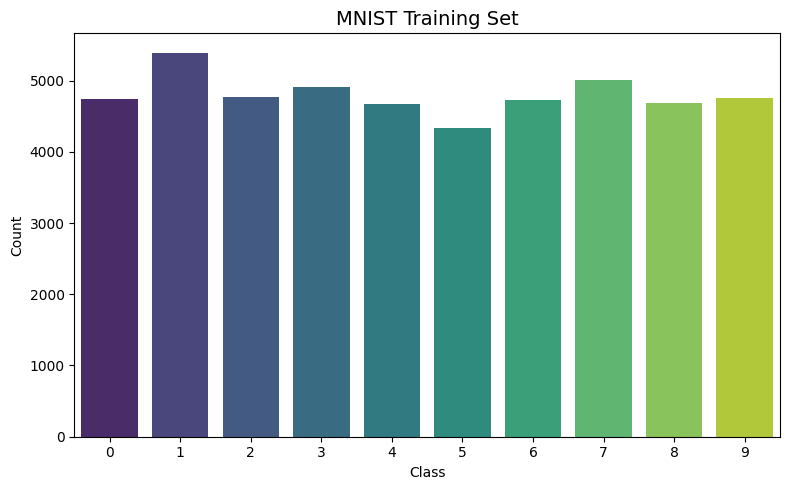

In [6]:
plot_class_distribution(y_train, title="MNIST Training Set")

In [7]:
from sklearn.tree import DecisionTreeClassifier

In [8]:
# Khởi tạo mô hình
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Huấn luyện trên tập train
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [9]:
from sklearn.metrics import accuracy_score

y_val_pred = clf.predict(X_val)
baseline_acc = accuracy_score(y_val, y_val_pred)
print(f"Baseline Accuracy (validation): {baseline_acc:.4f}")

Baseline Accuracy (validation): 0.8728


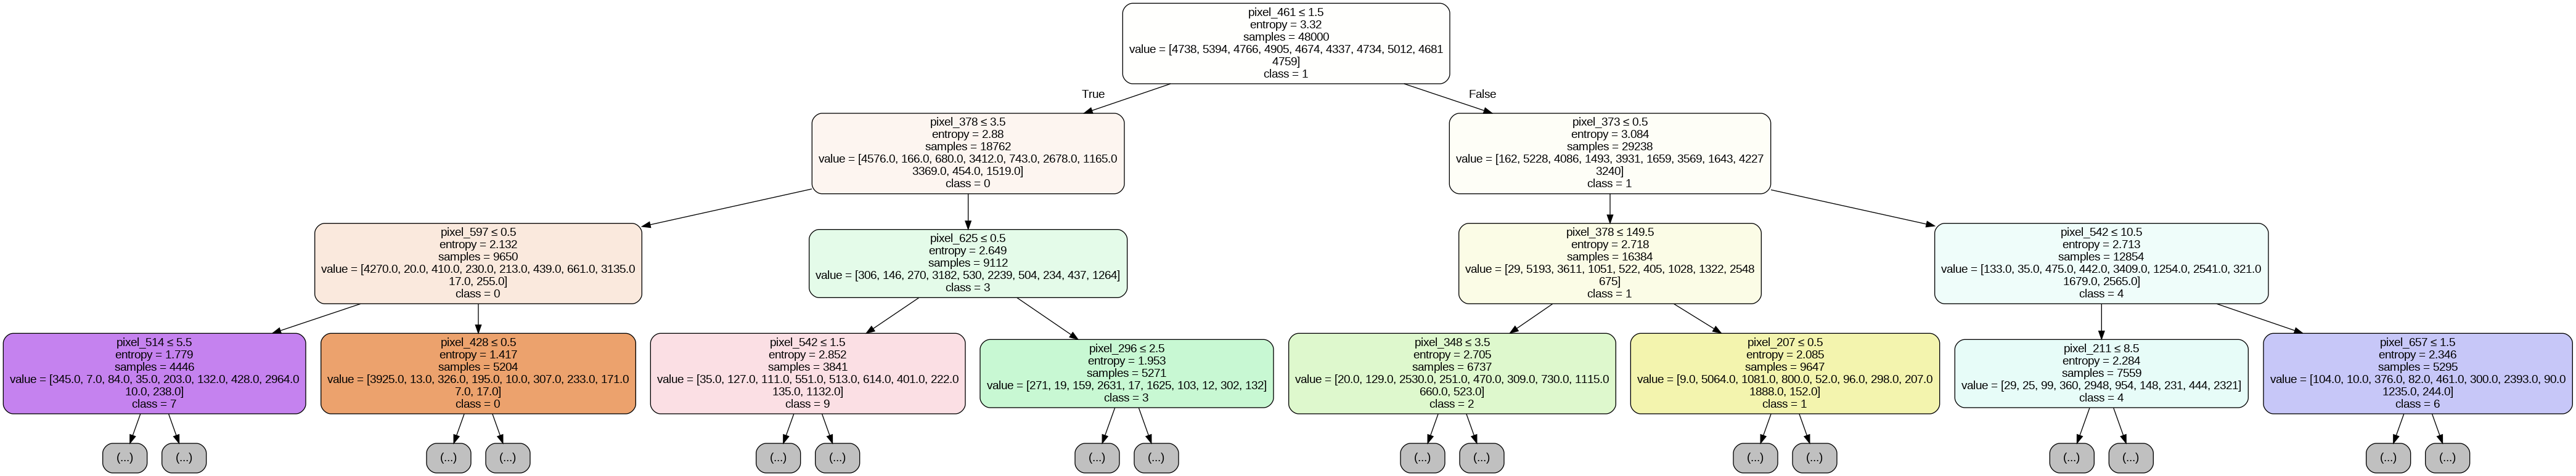

In [10]:
from sklearn.tree import export_graphviz
import graphviz

# Xuất cây dưới dạng dot
dot_data = export_graphviz(
    clf,
    out_file=None,
    feature_names=[f'pixel_{i}' for i in range(X_train.shape[1])],  # 784 feature
    class_names=[str(i) for i in range(10)],
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=3  # Giới hạn độ sâu để hình ảnh dễ nhìn (bạn có thể tăng lên nếu muốn)
)

# Vẽ cây
graph = graphviz.Source(dot_data)
graph.render(filename='figures/mnist_tree', format='png', cleanup=True)  # Lưu thành file PNG
from IPython.display import Image, display
display(Image(filename='figures/mnist_tree.png'))

Task 2.3 – Hyperparameter Tuning

In [14]:
# Task 2.3: Hyperparameter Tuning cho Decision Tree
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

# Định nghĩa các tham số cần tune
param_dist = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 10]
}

# Khởi tạo RandomizedSearchCV
clf_grid = DecisionTreeClassifier(criterion='entropy', random_state=42)
random_search = RandomizedSearchCV(
    clf_grid, 
    param_dist, 
    n_iter=20, 
    cv=3, 
    random_state=42, 
    n_jobs=-1, 
    verbose=2 # 
)
random_search.fit(X_train, y_train)

# In kết quả tốt nhất
print("Best parameters:", random_search.best_params_)
print("Best cross-validation accuracy:", random_search.best_score_)

# Đánh giá trên validation set
best_clf = random_search.best_estimator_
val_acc = best_clf.score(X_val, y_val)
print("Validation accuracy with best params:", val_acc)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
Best cross-validation accuracy: 0.8599375
Validation accuracy with best params: 0.8715833333333334
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   5.7s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   5.7s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   5.8s
[CV] END max_depth=10, min_samples_leaf=10, min_samples_split=20; total time=  12.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=10; total time=  12.3s
[CV] END max_depth=10, min_samples_leaf=10, min_samples_split=2; total time=  12.0s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=10; total time=  15.4s
[CV] END max_depth=5, min_samples_leaf=10, min_samples_split=2; total time=   5.8s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=5; total time=  14.8s
[CV] 

 Task 2.4: Xây dựng Neural Network (MLPClassifier)

In [15]:
from sklearn.neural_network import MLPClassifier

In [16]:
# 2. Khởi tạo mô hình MLP
# Theo yêu cầu, cần có ít nhất 1 hidden layer, non-linear activation và optimizer phù hợp.
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),        # 1 hidden layer với 100 neurons
    activation='relu',                # non-linear
    solver='adam',                    # optimizer
    learning_rate='adaptive',         # tự điều chỉnh learning rate
    max_iter=200,                     # số epoch tối đa
    early_stopping=True,              # dừng sớm nếu validation không cải thiện
    validation_fraction=0.1,          # 10% dữ liệu train dùng làm validation cho early stopping
    random_state=42
)

In [17]:
# 3. Huấn luyện và đánh giá trên validation set
mlp.fit(X_train, y_train)
val_acc_mlp = mlp.score(X_val, y_val)
print(f"MLP Validation Accuracy: {val_acc_mlp:.4f}")

MLP Validation Accuracy: 0.9509


Task 2.5: Đánh giá cuối cùng trên test set

In [19]:
import numpy as np

In [20]:
# 1. Huấn luyện lại mô hình Decision Tree với best params trên toàn bộ training set (gộp cả validation)
# Gộp train và validation
X_train_full = np.concatenate([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

# Decision Tree với best params
best_dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
best_dt.fit(X_train_full, y_train_full)

DecisionTreeClassifier(criterion='entropy', max_depth=20, random_state=42)

In [21]:
# 2. Huấn luyện lại MLP trên toàn bộ training set
mlp_full = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp_full.fit(X_train_full, y_train_full)

MLPClassifier(early_stopping=True, learning_rate='adaptive', random_state=42)


📊 KẾT QUẢ ĐÁNH GIÁ - Decision Tree (tuned)
Độ chính xác (Accuracy): 0.8867

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       980
           1       0.96      0.97      0.96      1135
           2       0.88      0.88      0.88      1032
           3       0.85      0.85      0.85      1010
           4       0.89      0.87      0.88       982
           5       0.83      0.84      0.84       892
           6       0.90      0.91      0.90       958
           7       0.91      0.90      0.91      1028
           8       0.85      0.84      0.85       974
           9       0.86      0.86      0.86      1009

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Đã lưu confusion matrix vào figures/mnist_dt_cm.png


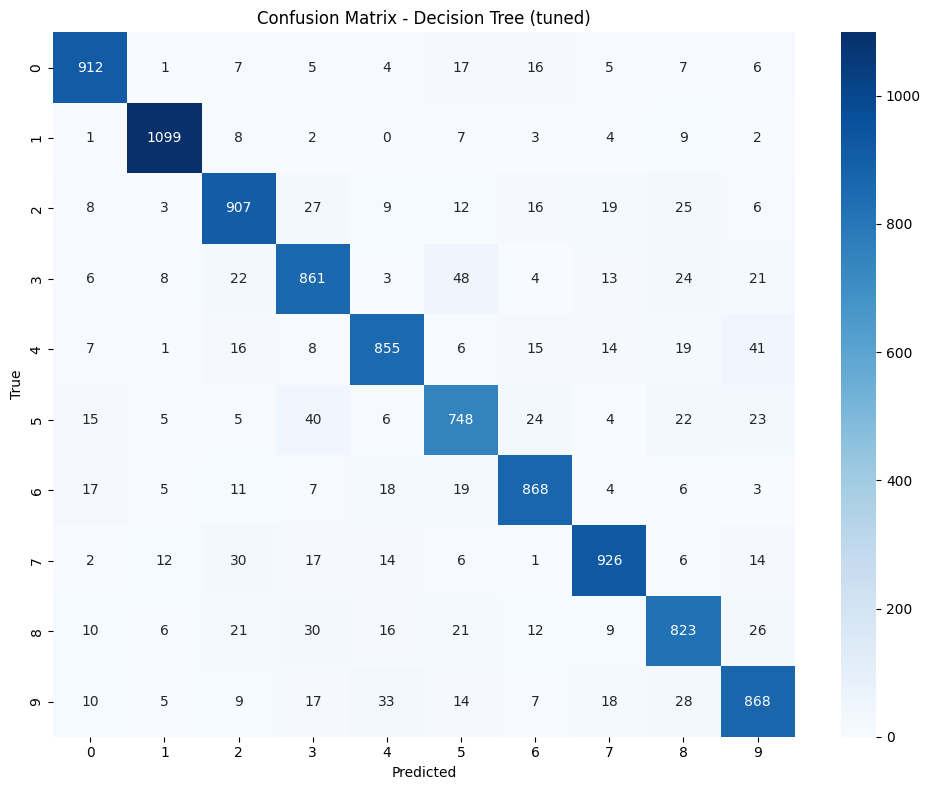


📊 KẾT QUẢ ĐÁNH GIÁ - MLP
Độ chính xác (Accuracy): 0.9661

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.96      0.96      1032
           3       0.97      0.96      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.96      0.95      0.96       892
           6       0.97      0.97      0.97       958
           7       0.96      0.98      0.97      1028
           8       0.94      0.95      0.95       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

Đã lưu confusion matrix vào figures/mnist_mlp_cm.png


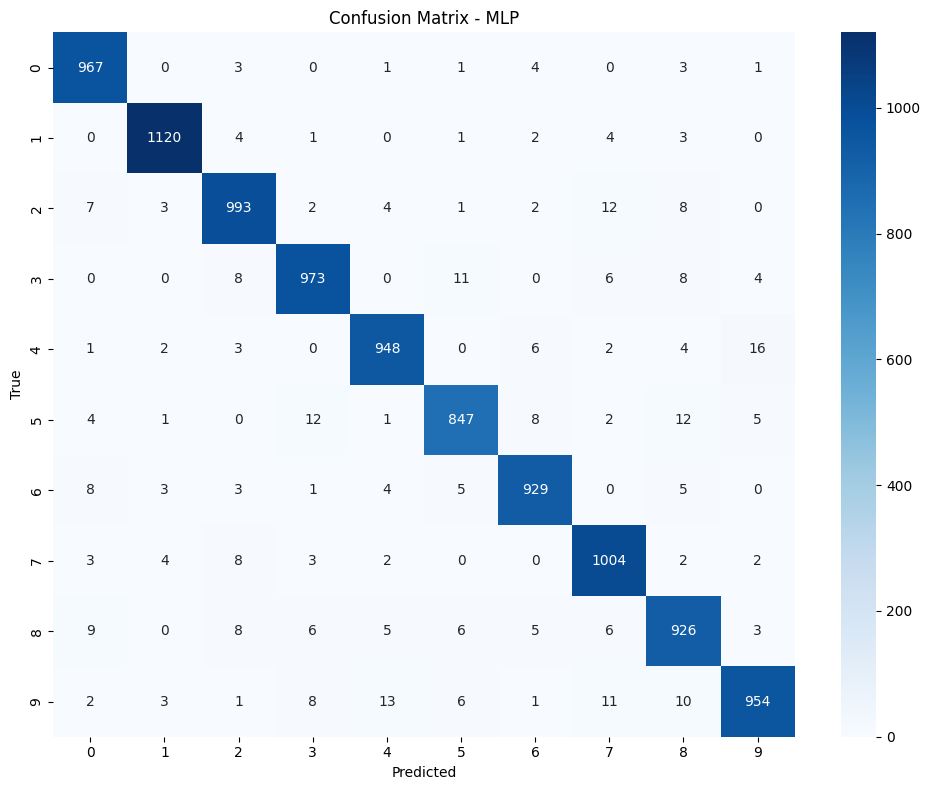

In [22]:
# 3. Đánh giá trên test set (dùng hàm evaluate_model trong helpers)
from utils.helpers import evaluate_model

# Decision Tree
dt_test_acc = evaluate_model(best_dt, X_test, y_test, 
                             model_name="Decision Tree (tuned)",
                             save_cm_path="figures/mnist_dt_cm.png",
                             class_names=[str(i) for i in range(10)])

# MLP
mlp_test_acc = evaluate_model(mlp_full, X_test, y_test,
                              model_name="MLP",
                              save_cm_path="figures/mnist_mlp_cm.png",
                              class_names=[str(i) for i in range(10)])

In [23]:
# 4. So sánh và insights
# In ra bảng so sánh accuracy:
print("\n=== Comparison ===")
print(f"Decision Tree Test Accuracy: {dt_test_acc[1]:.4f}")
print(f"MLP Test Accuracy: {mlp_test_acc[1]:.4f}")
# Dựa trên classification report và confusion matrix, bạn sẽ phân tích:

# Model nào tốt hơn? Tại sao?

# Class nào dễ nhầm lẫn nhất? (ví dụ: số 4 và 9, 3 và 5,...)

# Nhận xét về precision/recall cho từng class.


=== Comparison ===
Decision Tree Test Accuracy: 0.8867
MLP Test Accuracy: 0.9661
